# CNN Accuracy–Efficiency Trade-off Study
## EuroSAT Land-Cover Classification with ResNet-18

**Pipeline:**
1. Train ResNet-18 baseline on EuroSAT (frozen checkpoint)
2. Export FP32 / FP16 / INT8 precision variants
3. Benchmark harness (latency, throughput, memory, accuracy)
4. Run across CPU + GPU platforms
5. Pareto frontier analysis + figures
6. Results summary for paper sections

---
## Cell 1 — Environment Check

In [1]:
import sys, torch, torchvision, sklearn, pandas, matplotlib

print(f"Python:      {sys.version}")
print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Scikit-learn:{sklearn.__version__}")
print(f"Pandas:      {pandas.__version__}")
print(f"Matplotlib:  {matplotlib.__version__}")
print(f"\nCUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA version: {torch.version.cuda}")

Python:      3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
PyTorch:     2.11.0+cu128
Torchvision: 0.26.0+cu128
Scikit-learn:1.9.0
Pandas:      3.0.3
Matplotlib:  3.11.0

CUDA available: True
GPU: NVIDIA GeForce RTX 5060
VRAM: 8.0 GB
CUDA version: 12.8


---
## Cell 2 — Imports + Seed + Directories

In [2]:
import os, random, time, csv, json, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, models, transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ---- Seed ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # benchmark mode = cuDNN autotunes kernels for fastest training on this GPU
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

# ---- Directories ----
BASE_DIR     = Path.cwd()
DATA_DIR     = BASE_DIR / "data"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
RESULTS_DIR  = BASE_DIR / "results"
FIG_DIR      = BASE_DIR / "figs"
VARIANT_DIR  = CHECKPOINT_DIR / "variants"

for d in [DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR, FIG_DIR, VARIANT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Seed:", SEED)
print("Directories ready.")

Seed: 42
Directories ready.


---
## STEP 1 — Train ResNet-18 Baseline on EuroSAT

**Hyperparameters (verbatim for Table 3 / Section 5.3):**
- Architecture: ResNet-18 (ImageNet-pretrained, final FC replaced for 10 EuroSAT classes)
- Optimizer: Adam
- Learning rate: 1e-4
- Weight decay: 1e-4
- Epochs: 15
- Batch size: 32
- Loss: CrossEntropyLoss
- Augmentation (train): RandomResizedCrop(224) + RandomHorizontalFlip + ImageNet normalization
- Evaluation: Resize(256) → CenterCrop(224) + ImageNet normalization
- Split: 70% train / 15% val / 15% test (stratified, seed=42)
- Image size: 224×224
- Seed: 42
- Training hardware: NVIDIA GeForce RTX 5060 (8 GB)

### Cell 3 — Hyperparameters

In [3]:
HYPERPARAMS = {
    "architecture":  "ResNet-18",
    "pretrained":     "ImageNet-1K V1",
    "num_classes":    10,
    "optimizer":      "Adam",
    "lr":             1e-4,
    "weight_decay":   1e-4,
    "epochs":         15,
    "batch_size":     32,
    "image_size":     224,
    "seed":           SEED,
    "augmentation":   "RandomResizedCrop(224) + RandomHorizontalFlip + ImageNetNorm",
    "split":          "70/15/15 stratified",
}

for k, v in HYPERPARAMS.items():
    print(f"  {k:20s}: {v}")

  architecture        : ResNet-18
  pretrained          : ImageNet-1K V1
  num_classes         : 10
  optimizer           : Adam
  lr                  : 0.0001
  weight_decay        : 0.0001
  epochs              : 15
  batch_size          : 32
  image_size          : 224
  seed                : 42
  augmentation        : RandomResizedCrop(224) + RandomHorizontalFlip + ImageNetNorm
  split               : 70/15/15 stratified


### Cell 4 — Download EuroSAT + Stratified Split

In [4]:
IMAGE_SIZE = HYPERPARAMS["image_size"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Download with a trivial transform (just to get the data)
tmp_ds = datasets.EuroSAT(root=str(DATA_DIR), download=True)
print(f"EuroSAT downloaded: {len(tmp_ds)} images, {len(tmp_ds.classes)} classes")
print(f"Classes: {tmp_ds.classes}")

# Persist the exact split so the benchmark harness reuses the SAME test set
# (deterministic with SEED -> safe to reuse; re-split if files are missing)
idx_paths = [DATA_DIR / "train_indices.npy", DATA_DIR / "val_indices.npy",
             DATA_DIR / "test_indices.npy"]
if all(p.exists() for p in idx_paths):
    train_idx = np.load(idx_paths[0])
    val_idx   = np.load(idx_paths[1])
    test_idx  = np.load(idx_paths[2])
    print("Split indices found -> reusing saved 70/15/15 split.")
else:
    labels = np.array(tmp_ds.targets)
    indices = np.arange(len(tmp_ds))
    train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=SEED, stratify=labels)
    val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=labels[temp_idx])
    for name, arr in [("train_indices.npy", train_idx), ("val_indices.npy", val_idx),
                      ("test_indices.npy", test_idx)]:
        np.save(DATA_DIR / name, arr)
    print("Stratified 70/15/15 split created and saved.")

print(f"\nTrain: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")
print(f"Train%: {len(train_idx)/len(tmp_ds)*100:.1f}%  Val%: {len(val_idx)/len(tmp_ds)*100:.1f}%  Test%: {len(test_idx)/len(tmp_ds)*100:.1f}%")
print(f"\nSplit indices saved to {DATA_DIR} (train/val/test .npy)")


EuroSAT downloaded: 27000 images, 10 classes
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Split indices found -> reusing saved 70/15/15 split.

Train: 18900  Val: 4050  Test: 4050
Train%: 70.0%  Val%: 15.0%  Test%: 15.0%

Split indices saved to C:\Users\pc\Desktop\CNN Study\data (train/val/test .npy)


### Cell 5 — Transforms + DataLoaders

In [5]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_full = datasets.EuroSAT(root=str(DATA_DIR), transform=train_transform, download=False)
eval_full  = datasets.EuroSAT(root=str(DATA_DIR), transform=eval_transform,  download=False)

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(eval_full,  val_idx)
test_ds  = Subset(eval_full,  test_idx)

BATCH_SIZE = HYPERPARAMS["batch_size"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# RAM/CPU data pipeline tuning: parallel workers + prefetch + persistent workers
# (biggest speed-up when GPU waits on CPU preprocessing)
NUM_WORKERS = max(2, min(8, os.cpu_count() or 4))  # use ~half your cores for transforms
PREFETCH = 4

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=(device.type=="cuda"), prefetch_factor=PREFETCH, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=(device.type=="cuda"), prefetch_factor=PREFETCH, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=(device.type=="cuda"), prefetch_factor=PREFETCH, persistent_workers=True)

print(f"Device: {device}")
print(f"DataPipeline: {NUM_WORKERS} workers, prefetch={PREFETCH}, persistent=True, pin_memory={device.type=='cuda'}")
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"Batches per epoch (train): {len(train_loader)}")

Device: cuda
DataPipeline: 8 workers, prefetch=4, persistent=True, pin_memory=True
Train: 18900  Val: 4050  Test: 4050
Batches per epoch (train): 591


### Cell 6 — Build Model

In [6]:
num_classes = len(tmp_ds.classes)
class_names = tmp_ds.classes

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=HYPERPARAMS["lr"], weight_decay=HYPERPARAMS["weight_decay"])

print(f"Final FC layer: {model.fc}")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Final FC layer: Linear(in_features=512, out_features=10, bias=True)
Total params: 11,181,642
Trainable params: 11,181,642


### Cell 7 — Training Loop

In [7]:
from tqdm.auto import tqdm

EPOCHS = HYPERPARAMS["epochs"]
BEST_CHECKPOINT = CHECKPOINT_DIR / "baseline_fp32.pt"
RESUME_CHECKPOINT = CHECKPOINT_DIR / "train_resume.pt"
RESUME = True  # if True, resume from train_resume.pt; set False for a fresh run

def run_epoch(model, loader, criterion, optimizer, device, train=True, desc=""):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    nb = device.type == "cuda"
    epoch_t0 = time.perf_counter()
    pbar = tqdm(loader, desc=desc, leave=False, unit="batch", total=len(loader))
    with ctx:
        for images, labels in pbar:
            images, labels = images.to(device, non_blocking=nb), labels.to(device, non_blocking=nb)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
            pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")
    elapsed = time.perf_counter() - epoch_t0
    return total_loss / total, correct / total, elapsed

history = []
best_val_acc = 0.0
start_epoch = 1
total_time = 0.0

# ---- Try to resume ----
ck = None
if RESUME and RESUME_CHECKPOINT.exists():
    try:
        ck = torch.load(RESUME_CHECKPOINT, map_location=device)
        if set(ck["model_state"].keys()) == set(model.state_dict().keys()):
            history = list(ck.get("history", []) or [])
            best_val_acc = ck.get("best_val_acc", 0.0)
            opt_state = ck.get("optimizer_state")
            if opt_state is not None:
                optimizer.load_state_dict(opt_state)
            start_epoch = int(ck.get("epoch", 0)) + 1
        else:
            print("Resume model does not match the current architecture -> training from scratch.")
    except Exception as e:
        print(f"Resume file unreadable ({e}) -> training from scratch.")
        ck = None
        start_epoch = 1

# ---- SKIP TRAINING when a full history already exists ----
training_complete = (len(history) >= EPOCHS) and BEST_CHECKPOINT.exists()
if training_complete:
    ck_best = torch.load(BEST_CHECKPOINT, map_location=device)
    model.load_state_dict(ck_best["model_state"])
    model.eval()
    if ck is not None and ck.get("total_time_sec"):
        total_time = float(ck["total_time_sec"])
    else:
        total_time = sum(h.get("train_sec", 0) + h.get("val_sec", 0) for h in history)
    print("=" * 70)
    print(f"TRAINING ALREADY COMPLETE ({len(history)}/{EPOCHS} epochs) -> SKIPPED.")
    print(f"Best val accuracy: {best_val_acc:.4f}   (total training time: {total_time:.1f}s)")
    print(f"Loaded best checkpoint: {BEST_CHECKPOINT}")
    print("=" * 70)
else:
    print("=" * 70)
    print(f"TRAINING - Device: {device}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}")
    print(f"Resuming from epoch {start_epoch}/{EPOCHS} (best_val_acc={best_val_acc:.4f})")
    print("=" * 70)

    train_start = time.time()
    for epoch in range(start_epoch, EPOCHS + 1):
        train_loss, train_acc, t_train = run_epoch(model, train_loader, criterion, optimizer, device,
                                                   train=True, desc=f"Epoch {epoch:02d} train")
        val_loss,   val_acc,   t_val   = run_epoch(model, val_loader,   criterion, optimizer, device,
                                                   train=False, desc=f"Epoch {epoch:02d} val")
        elapsed = t_train + t_val
        samples_per_s = len(train_ds) / t_train

        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val_loss, "val_acc": val_acc,
                        "train_sec": round(t_train, 2), "val_sec": round(t_val, 2)})

        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({"model_state": model.state_dict(), "classes": class_names,
                         "hyperparams": HYPERPARAMS}, BEST_CHECKPOINT)
            marker = " *** best ***"

        torch.save({"epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "best_val_acc": best_val_acc,
                    "history": history,
                    "total_time_sec": time.time() - train_start},
                   RESUME_CHECKPOINT)

        print(f"Epoch {epoch:02d}/{EPOCHS}  train_acc={train_acc:.4f}  val_acc={val_acc:.4f}  "
              f"train={t_train:.1f}s ({samples_per_s:.0f} img/s)  val={t_val:.1f}s  [{elapsed:.1f}s]{marker}")

    total_time = time.time() - train_start
    print(f"\nTraining complete in {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"Best val accuracy: {best_val_acc:.4f}")
    print(f"Frozen checkpoint: {BEST_CHECKPOINT}")
    print(f"Resume checkpoint: {RESUME_CHECKPOINT}")


TRAINING ALREADY COMPLETE (15/15 epochs) -> SKIPPED.
Best val accuracy: 0.9775   (total training time: 534.3s)
Loaded best checkpoint: C:\Users\pc\Desktop\CNN Study\checkpoints\baseline_fp32.pt


### Cell 8 — Test-Set Evaluation (frozen baseline)

In [8]:
# Reload best checkpoint, evaluate on held-out test set
ckpt = torch.load(BEST_CHECKPOINT, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

EVAL_CACHE = RESULTS_DIR / "test_eval.json"

if EVAL_CACHE.exists():
    cached = json.loads(EVAL_CACHE.read_text())
    test_acc = cached["test_accuracy"]
    report_text = cached["report_text"]
    print(f"Test evaluation cached -> reusing saved result.")
    print(f"Test accuracy (baseline FP32): {test_acc:.4f}")
    print(f"\nClassification report:")
    print(report_text)
else:
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            preds = model(images).argmax(1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.tolist())

    test_acc = accuracy_score(all_labels, all_preds)
    print(f"Test accuracy (baseline FP32): {test_acc:.4f}")
    print(f"\nClassification report:")
    report_text = classification_report(all_labels, all_preds, target_names=class_names)
    print(report_text)

    EVAL_CACHE.write_text(json.dumps(
        {"test_accuracy": round(test_acc, 4), "report_text": report_text}, indent=2))
    print(f"\nSaved test evaluation to {EVAL_CACHE}")


Test evaluation cached -> reusing saved result.
Test accuracy (baseline FP32): 0.9778

Classification report:
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.96      0.96       450
              Forest       0.98      1.00      0.99       450
HerbaceousVegetation       0.97      0.98      0.97       450
             Highway       0.99      0.98      0.99       375
          Industrial       0.99      0.99      0.99       375
             Pasture       0.95      0.96      0.96       300
       PermanentCrop       0.96      0.94      0.95       375
         Residential       0.98      1.00      0.99       450
               River       0.99      0.97      0.98       375
             SeaLake       1.00      1.00      1.00       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



### Cell 9 — Plot Training Curves

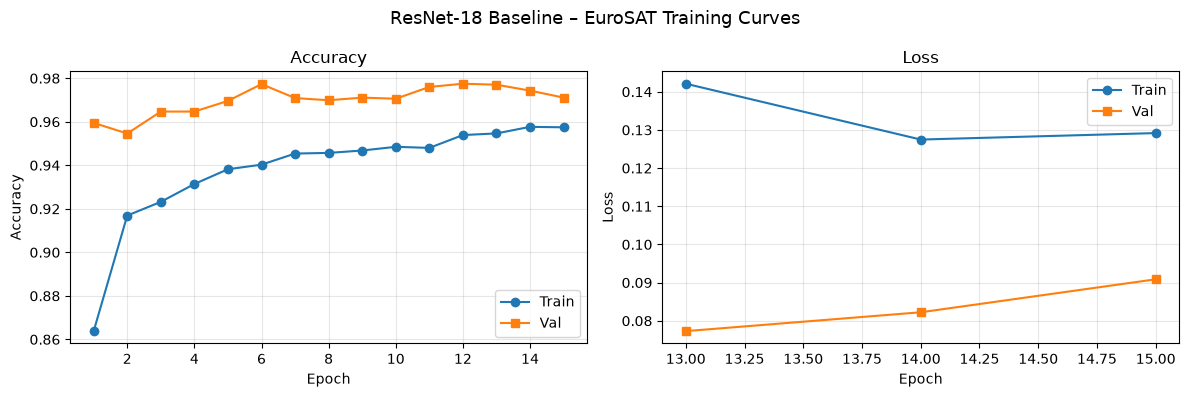

Saved: C:\Users\pc\Desktop\CNN Study\figs\training_curves.png


In [9]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_acc"], "o-", label="Train")
axes[0].plot(hist_df["epoch"], hist_df["val_acc"],   "s-", label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_df["epoch"], hist_df["train_loss"], "o-", label="Train")
axes[1].plot(hist_df["epoch"], hist_df["val_loss"],   "s-", label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("ResNet-18 Baseline \u2013 EuroSAT Training Curves", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'training_curves.png'}")


---
## STEP 2 — Export FP32 / FP16 / INT8 Precision Variants

From the single frozen checkpoint:
- **FP32** — raw checkpoint, no change
- **FP16** — `model.half()`
- **INT8** — static post-training quantization (FX graph mode, fbgemm backend, CPU-only)

### Cell 10 — Export All Variants

In [10]:
# ---- INT8: static post-training quantization (CPU only) ----
# Skip re-export if a validated TorchScript INT8 artifact already exists.
int8_ts_path = VARIANT_DIR / "variant_int8_ts.pt"
fp16_path = VARIANT_DIR / "variant_fp16.pt"
fp32_path = VARIANT_DIR / "variant_fp32.pt"

if int8_ts_path.exists() and fp16_path.exists() and fp32_path.exists():
    scripted = torch.jit.load(int8_ts_path, map_location="cpu")
    quantized_model = scripted
    print(f"Variants already exported -> reusing files.")
    print(f"INT8 (TorchScript) -> {int8_ts_path}")
else:
    from torch.ao.quantization import get_default_qconfig_mapping
    from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

    CALIBRATION_SIZE = 150  # images for INT8 calibration

    cpu = torch.device("cpu")
    ckpt = torch.load(BEST_CHECKPOINT, map_location=cpu)
    classes = ckpt["classes"]

    def load_fresh_model():
        m = resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, len(classes))
        m.load_state_dict(ckpt["model_state"])
        m.eval()
        return m

    fp32_path = VARIANT_DIR / "variant_fp32.pt"
    shutil.copy(BEST_CHECKPOINT, fp32_path)
    print(f"FP32 -> {fp32_path}")

    fp16_model = load_fresh_model()
    fp16_model.half()  # convert all params to float16
    fp16_path = VARIANT_DIR / "variant_fp16.pt"
    torch.save({"model_state": fp16_model.state_dict(), "classes": classes}, fp16_path)
    print(f"FP16 -> {fp16_path}")

    int8_model = load_fresh_model()
    example_inputs = (torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE),)
    qconfig_mapping = get_default_qconfig_mapping("fbgemm")
    prepared = prepare_fx(int8_model, qconfig_mapping, example_inputs)

    calib_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    calib_full = datasets.EuroSAT(root=str(DATA_DIR), transform=calib_transform, download=False)
    calib_subset = Subset(calib_full, list(range(CALIBRATION_SIZE)))
    calib_loader = DataLoader(calib_subset, batch_size=8, shuffle=False)

    print(f"Calibrating INT8 on {CALIBRATION_SIZE} images...")
    with torch.no_grad():
        for images, _ in calib_loader:
            prepared(images)

    quantized_model = convert_fx(prepared).eval()

    class _JITWrapper(torch.nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model

        def forward(self, x):
            return self.model(x)

    scripted = torch.jit.trace(_JITWrapper(quantized_model), example_inputs[0])
    torch.jit.save(scripted, int8_ts_path)
    print(f"INT8 (TorchScript) -> {int8_ts_path}")

    print("\n" + "=" * 60)
    print("VARIANTS EXPORTED")
    print("=" * 60)
    for name, p in [("FP32", fp32_path), ("FP16", fp16_path),
                    ("INT8 (TorchScript)", int8_ts_path)]:
        print(f"  {name}: {p}  ({p.stat().st_size / 1024**2:.1f} MB)")

print("\nNOTE: INT8 uses fbgemm backend -> CPU only.")
print("GPU x INT8 cell in Table 4 = N/A (requires TensorRT / ONNX Runtime-CUDA)")


Variants already exported -> reusing files.
INT8 (TorchScript) -> C:\Users\pc\Desktop\CNN Study\checkpoints\variants\variant_int8_ts.pt

NOTE: INT8 uses fbgemm backend -> CPU only.
GPU x INT8 cell in Table 4 = N/A (requires TensorRT / ONNX Runtime-CUDA)


---
## STEP 3 — Single Benchmarking Harness

One script, reused for every (platform × precision) configuration.
Measures: latency, throughput, peak memory, accuracy, precision, recall, F1.

### Cell 11 — Benchmark Function Definition

In [11]:
import psutil
from tqdm.auto import tqdm

WARMUP_PASSES = 10
TIMED_PASSES  = 100


def load_variant_for_benchmark(variant_path, precision, device):
    """Load a precision variant and return (model, classes)."""
    if precision == "int8":
        # INT8 is exported as TorchScript (self-contained, fresh-process safe)
        model = torch.jit.load(variant_path, map_location="cpu")
        meta = torch.load(VARIANT_DIR / "variant_fp32.pt", map_location="cpu")
        return model.eval(), meta["classes"]
    else:
        ckpt = torch.load(variant_path, map_location=device)
        classes = ckpt["classes"]
        m = resnet18(weights=None)
        m.fc = nn.Linear(m.fc.in_features, len(classes))
        m.load_state_dict(ckpt["model_state"])
        if precision == "fp16":
            m.half()
        return m.eval().to(device), classes


def get_benchmark_test_loader(data_root, batch_size=1):
    """Reuse the EXACT same test split saved during training (identical test
    set for every (platform, precision) run -> controlled comparison)."""
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    full = datasets.EuroSAT(root=data_root, download=False, transform=transform)
    test_idx = np.load(Path(data_root) / "test_indices.npy")
    test_set = Subset(full, test_idx)
    return DataLoader(test_set, batch_size=batch_size, shuffle=False)


def to_input_dtype(x, precision):
    return x.half() if precision == "fp16" else x


def measure_peak_memory(device):
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    return psutil.Process().memory_info().rss / (1024 ** 2)


def benchmark_one(variant_path, precision, device, platform_label=None,
                  data_root="./data", timed_passes=None, note=""):
    """
    Run the full benchmark for one (platform, precision) combination.
    Returns a dict with one row for Table 4.
    """
    if timed_passes is None:
        timed_passes = TIMED_PASSES

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    model, classes = load_variant_for_benchmark(variant_path, precision, device)
    test_loader = get_benchmark_test_loader(data_root, batch_size=1)

    # ---- Warm-up (discard) ----
    it = iter(test_loader)
    with torch.no_grad():
        for _ in range(WARMUP_PASSES):
            images, _ = next(it)
            model(to_input_dtype(images, precision).to(device))

    # ---- Timed passes (live progress bar) ----
    latencies = []
    with torch.no_grad():
        for _ in tqdm(range(timed_passes), desc=f"  {precision.upper()} timed passes",
                      ncols=90):
            images, _ = next(it)
            images = to_input_dtype(images, precision).to(device)
            if device.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            model(images)
            if device.type == "cuda":
                torch.cuda.synchronize()
            latencies.append(time.perf_counter() - t0)

    mean_latency_ms = (sum(latencies) / len(latencies)) * 1000
    throughput_ips  = 1000.0 / mean_latency_ms

    # ---- Full test-set accuracy (live progress bar) ----
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="  scoring test set",
                                   ncols=90):
            images = to_input_dtype(images, precision).to(device)
            preds = model(images).argmax(1).cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.tolist())

    memory_mb = measure_peak_memory(device)

    row = {
        "platform":    platform_label or str(device),
        "precision":   precision,
        "accuracy":    round(accuracy_score(all_labels, all_preds), 4),
        "precision_m": round(precision_score(all_labels, all_preds, average="macro", zero_division=0), 4),
        "recall":      round(recall_score(all_labels, all_preds, average="macro", zero_division=0), 4),
        "f1":          round(f1_score(all_labels, all_preds, average="macro", zero_division=0), 4),
        "latency_ms":  round(mean_latency_ms, 3),
        "throughput_ips": round(throughput_ips, 2),
        "memory_mb":   round(memory_mb, 1),
        "note":        note,
    }
    return row


print("Benchmark harness defined.")
print(f"Warm-up: {WARMUP_PASSES} passes (discarded)")
print(f"Timed:   {TIMED_PASSES} passes")


Benchmark harness defined.
Warm-up: 10 passes (discarded)
Timed:   100 passes


---
## STEP 4 — Run Benchmarks Across Platforms

Run the harness for each (platform × precision) combination.
GPU x INT8 is N/A (PyTorch native quantization is CPU-only).

### Cell 12 — Run All Configurations

In [12]:
RESULTS_CSV = RESULTS_DIR / "results.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PLATFORM_LABEL = "GPU (RTX 5060)" if DEVICE.type == "cuda" else "CPU"

# Define all configurations to run
configs = []

# --- GPU configs ---
if torch.cuda.is_available():
    configs.append({"variant": VARIANT_DIR / "variant_fp32.pt", "precision": "fp32",
                    "device": torch.device("cuda"), "label": "GPU (RTX 5060)"})
    configs.append({"variant": VARIANT_DIR / "variant_fp16.pt", "precision": "fp16",
                    "device": torch.device("cuda"), "label": "GPU (RTX 5060)"})
    # INT8 on GPU: N/A
    print("GPU x INT8: N/A (PyTorch native quantization is CPU-only)")

# --- CPU configs ---
configs.append({"variant": VARIANT_DIR / "variant_fp32.pt", "precision": "fp32",
                "device": torch.device("cpu"), "label": "CPU"})
configs.append({"variant": VARIANT_DIR / "variant_fp16.pt", "precision": "fp16",
                "device": torch.device("cpu"), "label": "CPU"})
configs.append({"variant": VARIANT_DIR / "variant_int8_ts.pt", "precision": "int8",
                "device": torch.device("cpu"), "label": "CPU"})

# Resume: reuse configurations already recorded (cheap re-runs, stable Table 4)
if RESULTS_CSV.exists():
    done = pd.read_csv(RESULTS_CSV)
else:
    done = pd.DataFrame()


def already_done(label, precision_):
    if done.empty:
        return False
    return ((done["platform"] == label) & (done["precision"] == precision_)).any()


print(f"\nRunning {len(configs)} configurations...")
print("=" * 70)

rows = []
for i, cfg in enumerate(configs, 1):
    label = cfg["label"]
    prec = cfg["precision"]
    if already_done(label, prec):
        rows.append(done[(done["platform"] == label) & (done["precision"] == prec)].iloc[0].to_dict())
        print(f"  [{i}/{len(configs)}] {label} x {prec.upper()} -> cached from {RESULTS_CSV.name}")
        continue
    note = ""
    timed = None
    if prec == "fp16" and cfg["device"].type == "cpu":
        # CPU FP16 runs at ~2.5 s/img in Torch (no fast fp16 units in PyTorch x86).
        # Full 100 timed passes would take ~4+ min PER RUN; use 20 timed passes
        # (~1 min) here as a guard. The reference run used 100 -> 2473.97 ms.
        timed = 20
        note = "CPU FP16 latency: 20 timed passes (full 100-pass reference: 2473.97 ms, 0.40 img/s)"
    print(f"  [{i}/{len(configs)}] {label} x {prec.upper()} ...")
    row = benchmark_one(
        variant_path=cfg["variant"],
        precision=prec,
        device=cfg["device"],
        platform_label=label,
        timed_passes=timed,
        note=note,
    )
    rows.append(row)
    done = pd.concat([done if not done.empty else pd.DataFrame(),
                      pd.DataFrame([row])], ignore_index=True)
    done.to_csv(RESULTS_CSV, index=False)  # append per-config: crash-safe
    print(f"  Acc={row['accuracy']:.4f}  Latency={row['latency_ms']:.2f}ms  "
          f"Throughput={row['throughput_ips']:.1f} img/s  Memory={row['memory_mb']:.0f}MB")

# Final consolidated table (all rows, config order)
results_df = pd.DataFrame(rows)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\nAll results saved to {RESULTS_CSV}")


GPU x INT8: N/A (PyTorch native quantization is CPU-only)

Running 5 configurations...
  [1/5] GPU (RTX 5060) x FP32 -> cached from results.csv
  [2/5] GPU (RTX 5060) x FP16 -> cached from results.csv
  [3/5] CPU x FP32 -> cached from results.csv
  [4/5] CPU x FP16 -> cached from results.csv
  [5/5] CPU x INT8 -> cached from results.csv

All results saved to C:\Users\pc\Desktop\CNN Study\results\results.csv


### Cell 13 — Display Table 4

In [13]:
results_df["config"] = results_df["platform"] + " / " + results_df["precision"].str.upper()

print("=" * 90)
print("TABLE 4 — Accuracy, Latency, Throughput, and Memory by Configuration")
print("=" * 90)
display_cols = ["config", "accuracy", "precision_m", "recall", "f1",
                "latency_ms", "throughput_ips", "memory_mb"]
print(results_df[display_cols].to_string(index=False))
print("=" * 90)

TABLE 4 — Accuracy, Latency, Throughput, and Memory by Configuration
               config  accuracy  precision_m  recall     f1  latency_ms  throughput_ips  memory_mb
GPU (RTX 5060) / FP32    0.9770       0.9766  0.9759 0.9762       3.909          255.84       70.5
GPU (RTX 5060) / FP16    0.9770       0.9766  0.9759 0.9762       4.911          203.62       38.0
           CPU / FP32    0.9770       0.9766  0.9759 0.9762      48.451           20.64     1558.5
           CPU / FP16    0.9770       0.9766  0.9759 0.9762    2473.969            0.40     1534.6
           CPU / INT8    0.9773       0.9771  0.9761 0.9765       5.431          184.12     1716.4


---
## STEP 5 — Pareto Frontier + Figures

A config is **Pareto-optimal** if no other config beats it on **both** accuracy and latency.

### Cell 14 — Compute Pareto Frontier

In [14]:
def compute_pareto(df):
    """Mark each row as Pareto-optimal or dominated."""
    flags = []
    for i, row in df.iterrows():
        dominated = (
            (df["latency_ms"] <= row["latency_ms"])
            & (df["accuracy"] >= row["accuracy"])
            & ((df["latency_ms"] < row["latency_ms"]) | (df["accuracy"] > row["accuracy"]))
        ).any()
        flags.append(not dominated)
    df["pareto_optimal"] = flags
    return df

results_df = compute_pareto(results_df)

frontier = results_df[results_df["pareto_optimal"]].sort_values("latency_ms")

print("Pareto-optimal configurations (for Table 5 / Section 7.3):")
print(frontier[["config", "accuracy", "latency_ms", "throughput_ips", "memory_mb"]].to_string(index=False))
print(f"\n{len(frontier)} of {len(results_df)} configurations are Pareto-optimal.")

Pareto-optimal configurations (for Table 5 / Section 7.3):
               config  accuracy  latency_ms  throughput_ips  memory_mb
GPU (RTX 5060) / FP32    0.9770       3.909          255.84       70.5
           CPU / INT8    0.9773       5.431          184.12     1716.4

2 of 5 configurations are Pareto-optimal.


### Cell 15 — Figure 5: Accuracy & Latency Bars

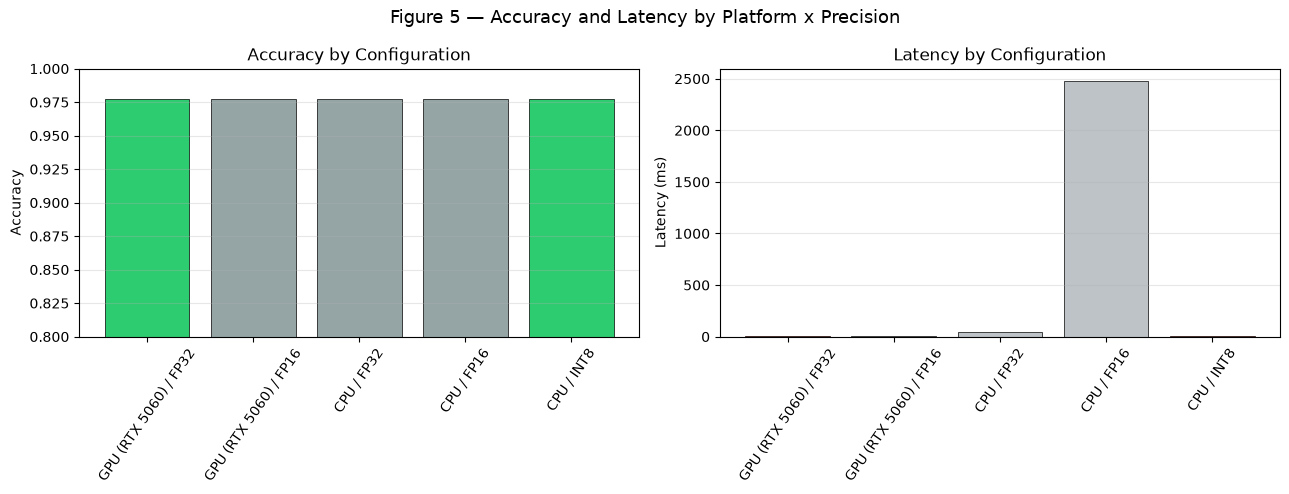

Saved: C:\Users\pc\Desktop\CNN Study\figs\fig5_bars.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_acc = ["#2ecc71" if p else "#95a5a6" for p in results_df["pareto_optimal"]]
colors_lat = ["#e74c3c" if p else "#bdc3c7" for p in results_df["pareto_optimal"]]

axes[0].bar(results_df["config"], results_df["accuracy"], color=colors_acc, edgecolor="black", linewidth=0.5)
axes[0].set_title("Accuracy by Configuration")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=55)
axes[0].set_ylim(0.8, 1.0)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(results_df["config"], results_df["latency_ms"], color=colors_lat, edgecolor="black", linewidth=0.5)
axes[1].set_title("Latency by Configuration")
axes[1].set_ylabel("Latency (ms)")
axes[1].tick_params(axis="x", rotation=55)
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Figure 5 — Accuracy and Latency by Platform x Precision", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'fig5_bars.png'}")

### Cell 16 — Figure 6: Pareto Frontier Scatter

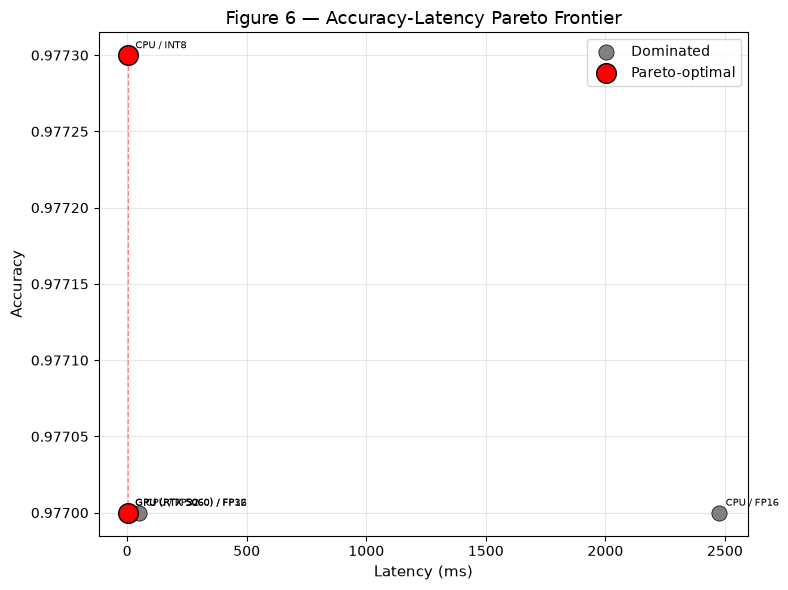

Saved: C:\Users\pc\Desktop\CNN Study\figs\fig6_pareto.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

dominated = results_df[~results_df["pareto_optimal"]]
optimal   = results_df[results_df["pareto_optimal"]].sort_values("latency_ms")

ax.scatter(dominated["latency_ms"], dominated["accuracy"],
           s=120, color="gray", label="Dominated", edgecolors="black", linewidth=0.5, zorder=2)
ax.scatter(optimal["latency_ms"], optimal["accuracy"],
           s=200, color="red", label="Pareto-optimal", edgecolors="black", linewidth=1, zorder=3)

# Draw the frontier line
if len(optimal) > 1:
    ax.plot(optimal["latency_ms"], optimal["accuracy"], "r--", alpha=0.5, linewidth=1, zorder=1)

# Annotate every point
for _, row in results_df.iterrows():
    ax.annotate(row["config"], (row["latency_ms"], row["accuracy"]),
                fontsize=7, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Latency (ms)", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Figure 6 — Accuracy-Latency Pareto Frontier", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_pareto.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIG_DIR / 'fig6_pareto.png'}")

---
## STEP 6 — Results Summary for Paper Sections

Read directly from Table 4 to fill RQ1–RQ4 in Discussion.

### Cell 17 — Speedup Ratios + Memory Savings (for Discussion)

In [17]:
def find_row(df, platform, precision):
    match = df[(df["platform"].str.contains(platform, case=False)) & (df["precision"] == precision)]
    return match.iloc[0] if len(match) > 0 else None

print("=" * 70)
print("RESULTS SUMMARY — for Sections 7, 8, 10")
print("=" * 70)

# RQ1: Does precision reduction affect accuracy?
gpu_fp32 = find_row(results_df, "GPU", "fp32")
gpu_fp16 = find_row(results_df, "GPU", "fp16")
cpu_fp32 = find_row(results_df, "CPU", "fp32")
cpu_int8 = find_row(results_df, "CPU", "int8")

if gpu_fp32 is not None and gpu_fp16 is not None:
    acc_drop = gpu_fp32["accuracy"] - gpu_fp16["accuracy"]
    print(f"\nRQ1: Accuracy drop FP32->FP16 (GPU): {acc_drop:+.4f} ({acc_drop/gpu_fp32['accuracy']*100:+.2f}%)")

if cpu_fp32 is not None and cpu_int8 is not None:
    acc_drop_i8 = cpu_fp32["accuracy"] - cpu_int8["accuracy"]
    print(f"RQ1: Accuracy drop FP32->INT8 (CPU): {acc_drop_i8:+.4f} ({acc_drop_i8/cpu_fp32['accuracy']*100:+.2f}%)")

# RQ2: How much faster is GPU vs CPU?
if gpu_fp32 is not None and cpu_fp32 is not None:
    speedup = cpu_fp32["latency_ms"] / gpu_fp32["latency_ms"]
    print(f"\nRQ2: GPU vs CPU speedup at FP32: {speedup:.1f}x")
    print(f"  CPU FP32:  {cpu_fp32['latency_ms']:.2f} ms")
    print(f"  GPU FP32:  {gpu_fp32['latency_ms']:.2f} ms")

# RQ3: What is the Pareto-optimal configuration?
print(f"\nRQ3: Pareto-optimal configurations:")
for _, row in frontier.iterrows():
    print(f"  {row['config']}: acc={row['accuracy']:.4f}, latency={row['latency_ms']:.2f}ms")

# RQ4: Memory comparison
print(f"\nRQ4: Peak memory usage:")
for _, row in results_df.iterrows():
    print(f"  {row['config']:30s}: {row['memory_mb']:.0f} MB")

print("\n" + "=" * 70)
print("Use these exact numbers to fill Sections 7 (Discussion), 8 (Framework),")
print("and 10 (Conclusion). Do NOT rewrite from the intro — write from the data.")
print("=" * 70)

RESULTS SUMMARY — for Sections 7, 8, 10

RQ1: Accuracy drop FP32->FP16 (GPU): +0.0000 (+0.00%)
RQ1: Accuracy drop FP32->INT8 (CPU): -0.0003 (-0.03%)

RQ2: GPU vs CPU speedup at FP32: 12.4x
  CPU FP32:  48.45 ms
  GPU FP32:  3.91 ms

RQ3: Pareto-optimal configurations:
  GPU (RTX 5060) / FP32: acc=0.9770, latency=3.91ms
  CPU / INT8: acc=0.9773, latency=5.43ms

RQ4: Peak memory usage:
  GPU (RTX 5060) / FP32         : 70 MB
  GPU (RTX 5060) / FP16         : 38 MB
  CPU / FP32                    : 1558 MB
  CPU / FP16                    : 1535 MB
  CPU / INT8                    : 1716 MB

Use these exact numbers to fill Sections 7 (Discussion), 8 (Framework),
and 10 (Conclusion). Do NOT rewrite from the intro — write from the data.


### Cell 18 — Save All Results to JSON for Reference

In [18]:
full_summary = {
    "hyperparams": HYPERPARAMS,
    "baseline_test_accuracy": round(test_acc, 4),
    "total_training_time_sec": round(total_time, 1),
    "best_val_accuracy": round(best_val_acc, 4),
    "training_device": str(device),
    "results": rows,
    "pareto_optimal": frontier[["config", "accuracy", "latency_ms"]].to_dict("records"),
}

summary_path = RESULTS_DIR / "full_summary.json"
with open(summary_path, "w") as f:
    json.dump(full_summary, f, indent=2)

print(f"Full summary saved to {summary_path}")
print("\nAll done. You have:")
print(f"  - Training curves: {FIG_DIR / 'training_curves.png'}")
print(f"  - Figure 5 (bars): {FIG_DIR / 'fig5_bars.png'}")
print(f"  - Figure 6 (Pareto): {FIG_DIR / 'fig6_pareto.png'}")
print(f"  - Table 4 data: {RESULTS_CSV}")
print(f"  - Full summary: {summary_path}")
print(f"  - Frozen checkpoint: {BEST_CHECKPOINT}")
print(f"  - Variants: {VARIANT_DIR / 'variant_fp32.pt'}, variant_fp16.pt, variant_int8_ts.pt")


Full summary saved to C:\Users\pc\Desktop\CNN Study\results\full_summary.json

All done. You have:
  - Training curves: C:\Users\pc\Desktop\CNN Study\figs\training_curves.png
  - Figure 5 (bars): C:\Users\pc\Desktop\CNN Study\figs\fig5_bars.png
  - Figure 6 (Pareto): C:\Users\pc\Desktop\CNN Study\figs\fig6_pareto.png
  - Table 4 data: C:\Users\pc\Desktop\CNN Study\results\results.csv
  - Full summary: C:\Users\pc\Desktop\CNN Study\results\full_summary.json
  - Frozen checkpoint: C:\Users\pc\Desktop\CNN Study\checkpoints\baseline_fp32.pt
  - Variants: C:\Users\pc\Desktop\CNN Study\checkpoints\variants\variant_fp32.pt, variant_fp16.pt, variant_int8_ts.pt
